# Phase 3: Baseline Model Comparison

## Objective

The objective of this notebook is to compare multiple machine learning algorithms using exactly the same validation strategy.

Only models that demonstrate superior cross-validation RMSE will proceed to hyperparameter optimization.

All comparisons are performed fairly using identical folds and evaluation metrics.

In [35]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

In [37]:
train = pd.read_csv("../data/processed/train_engineered.csv")
test = pd.read_csv("../data/processed/test_engineered.csv")

print(train.shape)
print(test.shape)

(150, 13)
(50, 12)


In [38]:
X = train.drop(columns=["overall_yield"])

y = train["overall_yield"]

print(X.shape)
print(y.shape)

(150, 12)
(150,)


In [39]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [40]:
rmse = make_scorer(
    mean_squared_error,
    squared=False
)

In [41]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge":
        Ridge(random_state=42),

    "Lasso":
        Lasso(random_state=42),

    "ElasticNet":
        ElasticNet(random_state=42),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(random_state=42),

    "Extra Trees":
        ExtraTreesRegressor(random_state=42),

    "Gradient Boosting":
        GradientBoostingRegressor(random_state=42),

    "Hist Gradient Boosting":
        HistGradientBoostingRegressor(random_state=42),

    "KNN":
        KNeighborsRegressor(),

    "SVR":
        SVR(),

    "MLP":
        MLPRegressor(
            random_state=42,
            max_iter=3000
        ),
    
    "XGBoost": XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0
    ),
}

In [42]:
results = []

for name, model in models.items():
    try:
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )

        results.append({
            "Model": name,
            "RMSE Mean": -scores.mean(),
            "RMSE Std": scores.std()
        })

    except Exception as e:
        print(f"{name} failed")
        print(e)

results = pd.DataFrame(results)

results = results.sort_values("RMSE Mean").reset_index(drop=True)

results

,Model,RMSE Mean,RMSE Std
0,XGBoost,19.515318,2.894609
1,Extra Trees,19.601863,1.591564
2,CatBoost,20.501288,2.566162
3,Random Forest,21.221278,2.897726
4,Gradient Boosting,22.627685,2.344378
5,LightGBM,23.791541,4.181820
6,Hist Gradient Boosting,23.980033,2.970356
7,Decision Tree,27.913178,5.151457
8,Linear Regression,29.356470,2.082113
9,Ridge,30.113659,1.662192


In [43]:
results = results.sort_values(

    "RMSE Mean"

)

results

,Model,RMSE Mean,RMSE Std
0,XGBoost,19.515318,2.894609
1,Extra Trees,19.601863,1.591564
2,CatBoost,20.501288,2.566162
3,Random Forest,21.221278,2.897726
4,Gradient Boosting,22.627685,2.344378
5,LightGBM,23.791541,4.181820
6,Hist Gradient Boosting,23.980033,2.970356
7,Decision Tree,27.913178,5.151457
8,Linear Regression,29.356470,2.082113
9,Ridge,30.113659,1.662192


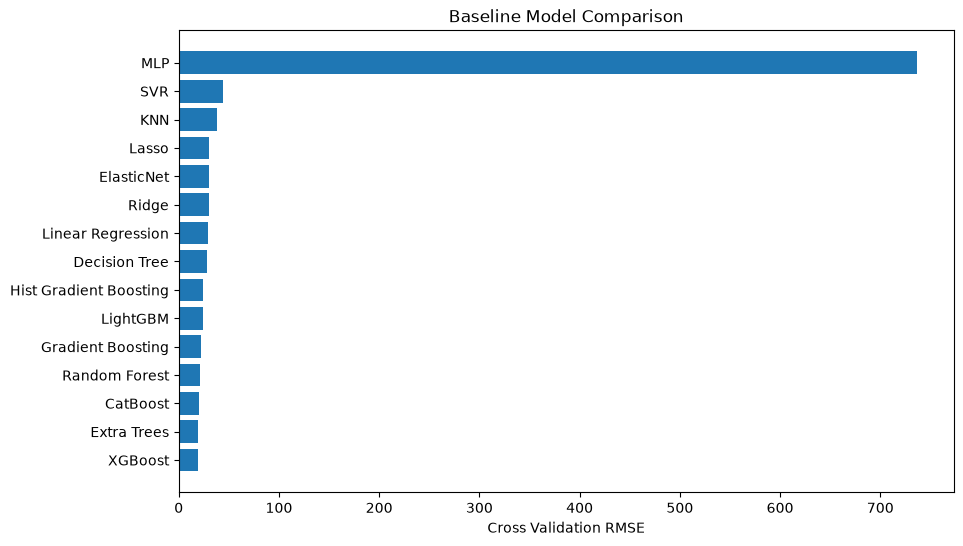

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    results["Model"],

    results["RMSE Mean"]

)

plt.xlabel("Cross Validation RMSE")

plt.title("Baseline Model Comparison")

plt.show()

In [45]:
results.to_csv(

    "../reports/baseline_results.csv",

    index=False

)

# Baseline Model Comparison

The baseline experiment compares multiple regression algorithms using identical cross-validation folds.

The comparison identifies the strongest candidates for hyperparameter optimization.

Only the models demonstrating consistently low validation RMSE will proceed to the optimization phase.

Training performance is intentionally ignored because leaderboard performance depends on generalization rather than memorization.

In [46]:
results

,Model,RMSE Mean,RMSE Std
0,XGBoost,19.515318,2.894609
1,Extra Trees,19.601863,1.591564
2,CatBoost,20.501288,2.566162
3,Random Forest,21.221278,2.897726
4,Gradient Boosting,22.627685,2.344378
5,LightGBM,23.791541,4.181820
6,Hist Gradient Boosting,23.980033,2.970356
7,Decision Tree,27.913178,5.151457
8,Linear Regression,29.356470,2.082113
9,Ridge,30.113659,1.662192


In [47]:
results = []

for name, model in models.items():

    print("=" * 60)
    print(name)

    try:

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )

        print(scores)

        results.append({
            "Model": name,
            "RMSE Mean": -scores.mean(),
            "RMSE Std": scores.std()
        })

    except Exception as e:

        print("FAILED")
        print(type(e).__name__)
        print(e)

Linear Regression
[-30.27351071 -30.16582077 -32.24893833 -26.28985564 -27.804225  ]
Ridge
[-31.41665927 -31.96625577 -29.93649769 -27.17227685 -30.0766059 ]
Lasso
[-31.89483819 -31.83360138 -29.63729736 -27.57363208 -30.31265677]
ElasticNet
[-31.84937543 -31.783411   -29.57615142 -27.49208722 -30.27097378]
Decision Tree
[-34.30543266 -31.30144315 -24.56669058 -19.77432766 -29.61799604]
Random Forest
[-22.70195529 -24.73467496 -23.08078791 -18.29654439 -17.29242663]
Extra Trees
[-19.55520662 -21.26735938 -20.94871734 -16.76298513 -19.47504782]
Gradient Boosting
[-25.47291874 -24.84812037 -22.69845782 -20.85266331 -19.26626512]
Hist Gradient Boosting
[-23.39841502 -26.41947638 -27.75403439 -23.12932986 -19.19891117]
KNN
[-40.92739485 -45.08839366 -31.52778435 -35.35553651 -35.73491878]
SVR
[-44.25909826 -55.40708405 -37.89802264 -40.57514375 -43.87688305]
MLP
[-714.65837987 -700.10572018 -790.9154709  -736.59728287 -739.85106682]
XGBoost
[-20.35507206 -22.68795356 -22.31639927 -16.28920

In [48]:
import xgboost
import lightgbm
import catboost
import optuna

print("Core libraries installed successfully!")

Core libraries installed successfully!


In [49]:
results

[{'Model': 'Linear Regression',
  'RMSE Mean': np.float64(29.356470089862842),
  'RMSE Std': np.float64(2.082113040531555)},
 {'Model': 'Ridge',
  'RMSE Mean': np.float64(30.113659097045808),
  'RMSE Std': np.float64(1.6621920754208417)},
 {'Model': 'Lasso',
  'RMSE Mean': np.float64(30.250405154970245),
  'RMSE Std': np.float64(1.5972201349928827)},
 {'Model': 'ElasticNet',
  'RMSE Mean': np.float64(30.194399767575426),
  'RMSE Std': np.float64(1.6096265927468318)},
 {'Model': 'Decision Tree',
  'RMSE Mean': np.float64(27.91317801443564),
  'RMSE Std': np.float64(5.15145664523737)},
 {'Model': 'Random Forest',
  'RMSE Mean': np.float64(21.22127783573307),
  'RMSE Std': np.float64(2.8977260183880515)},
 {'Model': 'Extra Trees',
  'RMSE Mean': np.float64(19.601863258427862),
  'RMSE Std': np.float64(1.5915640912753213)},
 {'Model': 'Gradient Boosting',
  'RMSE Mean': np.float64(22.627685073775734),
  'RMSE Std': np.float64(2.3443780686718534)},
 {'Model': 'Hist Gradient Boosting',
  'RM